In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sanyasiraokoll/indian-pines/Indian_pines_corrected.mat
/kaggle/input/datasets/sanyasiraokoll/indian-pines/Indian_pines_gt.mat
/kaggle/input/datasets/sanyasiraokoll/houston-full/HOUSTON_NEEDED_FULL_DATASET/Test_Labels.tif
/kaggle/input/datasets/sanyasiraokoll/houston-full/HOUSTON_NEEDED_FULL_DATASET/20170218_UH_CASI_S4_NAD83.pix
/kaggle/input/datasets/sanyasiraokoll/houston-full/HOUSTON_NEEDED_FULL_DATASET/2018_IEEE_GRSS_DFC_GT_TR.tif
/kaggle/input/datasets/sanyasiraokoll/houston-full/HOUSTON_NEEDED_FULL_DATASET/20170218_UH_CASI_S4_NAD83.hdr


In [2]:
!pip install spectral -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 6.2 MB/s eta 0:00:00:00:01


In [3]:
!pip show torch

Name: torch
Version: 2.10.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvshmem-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, easyocr, fastai, kornia, peft, pytorch-ignite, pytorch-lightning, sentence-transformers, timm, torchaudio, torchdata, torchmetrics, torchvision


In [4]:
import os
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt

from spectral import open_image

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score
)

warnings.filterwarnings("ignore")

In [5]:
from spectral import open_image
import spectral

In [6]:
NUM_CLIENTS = 4

PATCH_SIZE = 128

# Paper = 0.40
# Kaggle Safe = 0.2
OVERLAP = 0.40
# Paper = 2000
# Kaggle Safe = 500
DIFFUSION_TIMESTEPS = 2000

# Paper = 500000 local epochs
# Kaggle Safe = 100
DIFFUSION_EPOCHS = 100

# Paper = 80
# Kaggle Safe = 30
UNMIX_EPOCHS = 80
NUM_ENDMEMBERS = 5

COMMUNICATION_ROUNDS = 4

LOCAL_CLASSIFIER_EPOCHS = 2

print("Parameters loaded")

Parameters loaded


In [7]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [8]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [11]:
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("synthetic", exist_ok=True)

In [12]:
DATA_DIR = "/kaggle/input/datasets/sanyasiraokoll/indian-pines"

HSI_FILE = f"{DATA_DIR}/Indian_pines_corrected.mat"
GT_FILE  = f"{DATA_DIR}/Indian_pines_gt.mat"

In [13]:
from scipy.io import loadmat

hsi_data = loadmat(HSI_FILE)
gt_data  = loadmat(GT_FILE)

X = hsi_data["indian_pines_corrected"]
Y = gt_data["indian_pines_gt"]

print(X.shape)
print(Y.shape)

(145, 145, 200)
(145, 145)


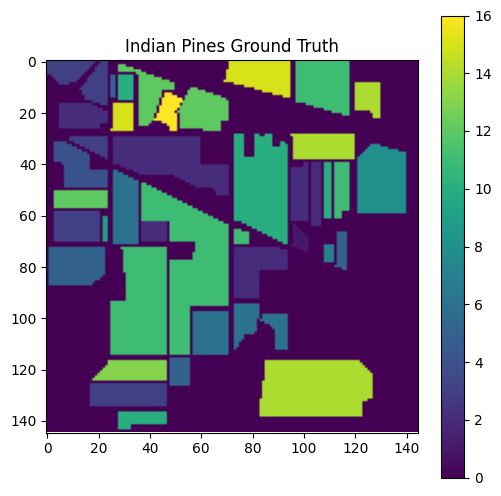

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(Y)
plt.colorbar()
plt.title("Indian Pines Ground Truth")
plt.show()

In [16]:
print("Unique Labels:")
print(np.unique(Y))

print()
print("Number of Classes:")
print(len(np.unique(Y)) - 1)

Unique Labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]

Number of Classes:
16


In [17]:
valid_labels = sorted(
    [x for x in np.unique(Y) if x > 0]
)

print(valid_labels)

[np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16)]


In [18]:
from collections import Counter

counter = Counter(Y[Y > 0].flatten())

for cls in valid_labels:
    print(
        f"Class {cls}: {counter[cls]}"
    )

Class 1: 46
Class 2: 1428
Class 3: 830
Class 4: 237
Class 5: 483
Class 6: 730
Class 7: 28
Class 8: 478
Class 9: 20
Class 10: 972
Class 11: 2455
Class 12: 593
Class 13: 205
Class 14: 1265
Class 15: 386
Class 16: 93


In [19]:
label_map = {
    cls: i
    for i, cls in enumerate(valid_labels)
}

print(label_map)

{np.uint8(1): 0, np.uint8(2): 1, np.uint8(3): 2, np.uint8(4): 3, np.uint8(5): 4, np.uint8(6): 5, np.uint8(7): 6, np.uint8(8): 7, np.uint8(9): 8, np.uint8(10): 9, np.uint8(11): 10, np.uint8(12): 11, np.uint8(13): 12, np.uint8(14): 13, np.uint8(15): 14, np.uint8(16): 15}


In [20]:
PATCH_SIZE = 7
PAD = PATCH_SIZE // 2

X_pad = np.pad(
    X,
    ((PAD, PAD),
     (PAD, PAD),
     (0, 0)),
    mode="reflect"
)

print(X_pad.shape)

(151, 151, 200)


In [21]:
X_patches = []
y_labels = []

for r in range(Y.shape[0]):

    for c in range(Y.shape[1]):

        cls = Y[r, c]

        if cls == 0:
            continue

        patch = X_pad[
            r:r+PATCH_SIZE,
            c:c+PATCH_SIZE,
            :
        ]

        patch = patch.transpose(2, 0, 1)

        X_patches.append(
            patch.astype(np.float32)
        )

        y_labels.append(
            label_map[cls]
        )

X_patches = np.array(X_patches)
y_labels = np.array(y_labels)

print(X_patches.shape)
print(y_labels.shape)

(10249, 200, 7, 7)
(10249,)


In [22]:
from collections import Counter

counter = Counter(y_labels)

for cls in sorted(counter.keys()):
    print(
        f"Class {cls}: {counter[cls]}"
    )

Class 0: 46
Class 1: 1428
Class 2: 830
Class 3: 237
Class 4: 483
Class 5: 730
Class 6: 28
Class 7: 478
Class 8: 20
Class 9: 972
Class 10: 2455
Class 11: 593
Class 12: 205
Class 13: 1265
Class 14: 386
Class 15: 93


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_patches,
    y_labels,
    test_size=0.60,
    stratify=y_labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (4099, 200, 7, 7)
Val  : (3075, 200, 7, 7)
Test : (3075, 200, 7, 7)


In [24]:
X_train = X_train[:, None, :, :, :]
X_val   = X_val[:, None, :, :, :]
X_test  = X_test[:, None, :, :, :]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4099, 1, 200, 7, 7)
(3075, 1, 200, 7, 7)
(3075, 1, 200, 7, 7)


In [25]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

In [26]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 128

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [27]:
x, y = next(iter(train_loader))

print(x.shape)
print(y.shape)

print(torch.unique(y))

torch.Size([128, 1, 200, 7, 7])
torch.Size([128])
tensor([ 1,  2,  3,  4,  5,  7,  8,  9, 10, 11, 12, 13, 14, 15])


In [28]:
import torch
import torch.nn as nn

class HSI3DCNN_Attention_Transformer(nn.Module):

    def __init__(self, num_classes=19):

        super().__init__()

        # ==========================================
        # 3D CNN FEATURE EXTRACTOR
        # ==========================================
        self.features = nn.Sequential(

            nn.Conv3d(
                1, 8,
                kernel_size=(7,3,3),
                padding=(3,1,1)
            ),
            nn.BatchNorm3d(8),
            nn.ReLU(),

            nn.MaxPool3d((2,2,2)),

            nn.Conv3d(
                8, 16,
                kernel_size=(5,3,3),
                padding=(2,1,1)
            ),
            nn.BatchNorm3d(16),
            nn.ReLU(),

            nn.MaxPool3d((2,2,2)),

            nn.Conv3d(
                16, 32,
                kernel_size=(3,3,3),
                padding=1
            ),
            nn.BatchNorm3d(32),
            nn.ReLU()
        )

        # ==========================================
        # CHANNEL (SPECTRAL) ATTENTION
        # ==========================================
        self.channel_attention = nn.Sequential(

            nn.AdaptiveAvgPool3d(1),

            nn.Conv3d(
                32,
                8,
                kernel_size=1
            ),

            nn.ReLU(),

            nn.Conv3d(
                8,
                32,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

        # ==========================================
        # SPATIAL ATTENTION
        # ==========================================
        self.spatial_attention = nn.Sequential(

            nn.Conv3d(
                32,
                1,
                kernel_size=3,
                padding=1
            ),

            nn.Sigmoid()
        )

        # ==========================================
        # TRANSFORMER
        # ==========================================
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=32,
            nhead=4,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        # ==========================================
        # CLASSIFIER
        # ==========================================
        self.classifier = nn.Sequential(

            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        # ==========================================
        # CNN FEATURES
        # ==========================================
        x = self.features(x)

        # ==========================================
        # CHANNEL ATTENTION
        # ==========================================
        ca = self.channel_attention(x)
        x = x * ca

        # ==========================================
        # SPATIAL ATTENTION
        # ==========================================
        sa = self.spatial_attention(x)
        x = x * sa

        # ==========================================
        # REAL TRANSFORMER TOKENS
        # ==========================================
        B, C, D, H, W = x.shape

        # (B,C,D,H,W) -> (B,C,N)
        x = x.view(B, C, D * H * W)

        # (B,C,N) -> (B,N,C)
        x = x.permute(0, 2, 1)

        # DEBUG
        # print("Transformer Input:", x.shape)

        # Transformer
        x = self.transformer(x)

        # Global token pooling
        x = x.mean(dim=1)

        # ==========================================
        # CLASSIFICATION
        # ==========================================
        x = self.classifier(x)

        return x

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HSI3DCNN_Attention_Transformer(
    num_classes=16
).to(device)

In [31]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
     lr=3e-4
)

In [36]:
EPOCHS = 200

best_val_acc = 0

for epoch in range(EPOCHS):

    # =====================
    # TRAIN
    # =====================

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for x, y in train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        pred = logits.argmax(1)

        train_correct += (
            pred == y
        ).sum().item()

        train_total += y.size(0)

    train_acc = (
        100 * train_correct /
        train_total
    )

    # =====================
    # VALIDATION
    # =====================

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x)

            pred = logits.argmax(1)

            val_correct += (
                pred == y
            ).sum().item()

            val_total += y.size(0)

    val_acc = (
        100 * val_correct /
        val_total
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_3dcnn.pt"
        )

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch 01 | Train Acc: 69.29% | Val Acc: 14.99%
Epoch 02 | Train Acc: 52.21% | Val Acc: 47.32%
Epoch 03 | Train Acc: 61.06% | Val Acc: 58.63%
Epoch 04 | Train Acc: 66.11% | Val Acc: 58.54%
Epoch 05 | Train Acc: 65.60% | Val Acc: 46.50%
Epoch 06 | Train Acc: 68.58% | Val Acc: 56.91%
Epoch 07 | Train Acc: 68.28% | Val Acc: 66.44%
Epoch 08 | Train Acc: 67.50% | Val Acc: 54.86%
Epoch 09 | Train Acc: 69.53% | Val Acc: 64.75%
Epoch 10 | Train Acc: 68.99% | Val Acc: 65.66%
Epoch 11 | Train Acc: 69.87% | Val Acc: 67.80%
Epoch 12 | Train Acc: 68.82% | Val Acc: 33.92%
Epoch 13 | Train Acc: 63.48% | Val Acc: 50.34%
Epoch 14 | Train Acc: 70.19% | Val Acc: 63.02%
Epoch 15 | Train Acc: 69.14% | Val Acc: 71.19%
Epoch 16 | Train Acc: 69.38% | Val Acc: 63.48%
Epoch 17 | Train Acc: 70.99% | Val Acc: 66.96%
Epoch 18 | Train Acc: 71.58% | Val Acc: 65.24%
Epoch 19 | Train Acc: 65.14% | Val Acc: 56.91%
Epoch 20 | Train Acc: 64.67% | Val Acc: 52.81%
Epoch 21 | Train Acc: 65.80% | Val Acc: 56.65%
Epoch 22 | Tr

In [38]:
model.load_state_dict(
    torch.load(
        "best_3dcnn.pt"
    )
)

<All keys matched successfully>

In [39]:
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix
)

import numpy as np

model.eval()

all_pred = []
all_true = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(DEVICE)

        logits = model(x)

        pred = logits.argmax(1)

        all_pred.extend(
            pred.cpu().numpy()
        )

        all_true.extend(
            y.numpy()
        )

OA = accuracy_score(
    all_true,
    all_pred
)

cm = confusion_matrix(
    all_true,
    all_pred
)

AA = np.mean(
    cm.diagonal() /
    cm.sum(axis=1)
)

Kappa = cohen_kappa_score(
    all_true,
    all_pred
)

print(f"OA: {OA*100:.2f}%")
print(f"AA: {AA*100:.2f}%")
print(f"Kappa: {Kappa:.4f}")

OA: 83.87%
AA: 78.01%
Kappa: 0.8159
